Pipeline template

Notebook to illustrate the overall pipeline flow including:

- reading in data
- adding non signal noise
- modifying record to be input ready
- inputting to DMD
- converting recovered outputs to comparable outputs
- examining recovery metrics

## Preamble

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing
from matplotlib.colors import BoundaryNorm


# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Application
['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/m

## Reading in global data

### Plan

1) loading in the data

2) run the synthetic comparison test with modes rank-degree heatmap

3) create a control set from best performance

4) use these to run a control set test under uncertainty for the record

5) see what is recovered correctly - also what spurious signals may or may not appear

In [3]:
# Defining test parameters

# defining modes used
mode_numbers = ['62', '6', '13', '48', '45', '1', '32']
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

# getting full (nmax=15) unperturbed records and synthetic suite info
record_dict_global, syn_suite_info_global = Record_Dict_Construct(mode_numbers=mode_numbers, nmax=15)

# defining notebook global colours for each mode in plotting
for i, mode_key in enumerate(syn_suite_info_global):
    syn_suite_info_global[mode_key]["colour"] = tol_muted[i % len(tol_muted)]

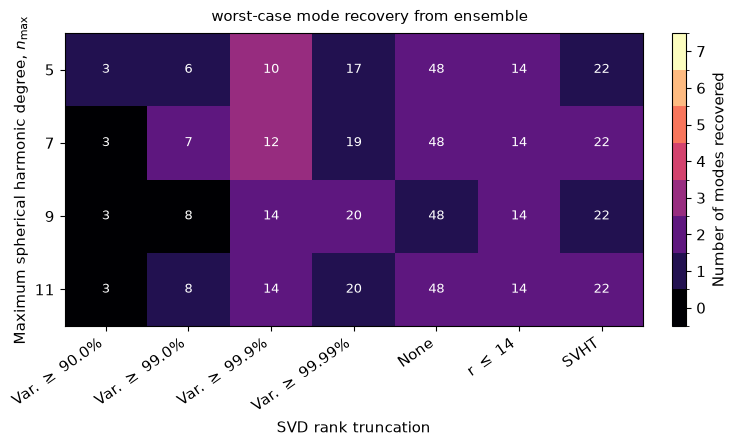

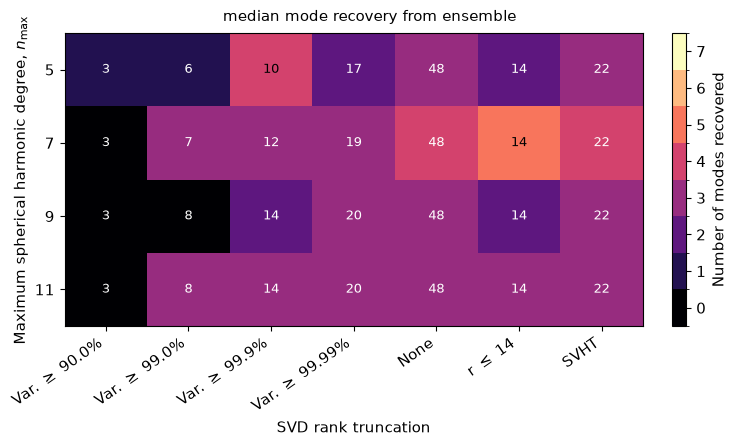

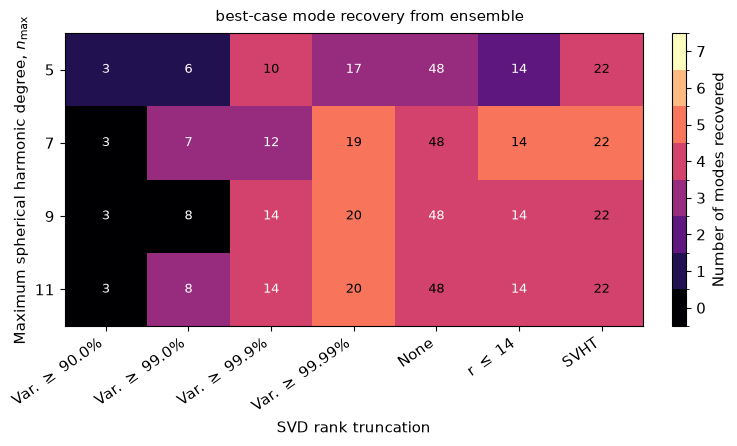

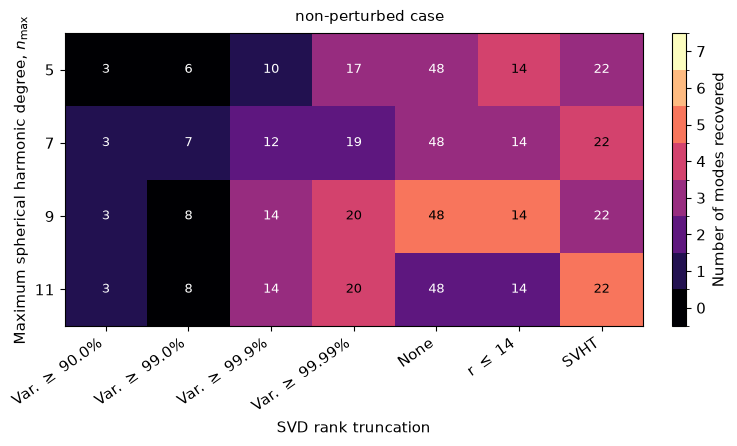

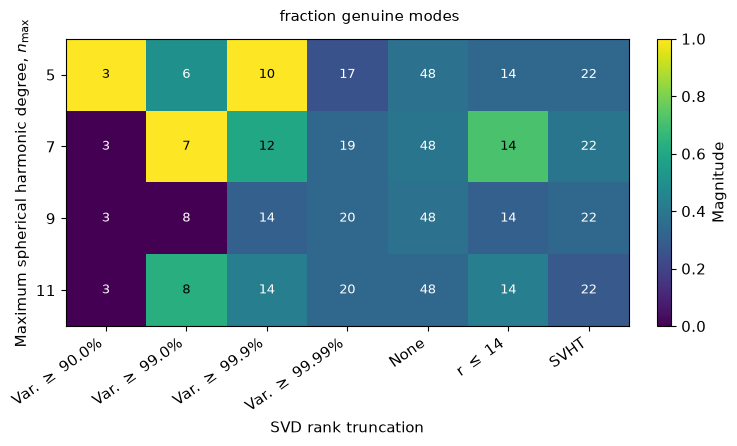

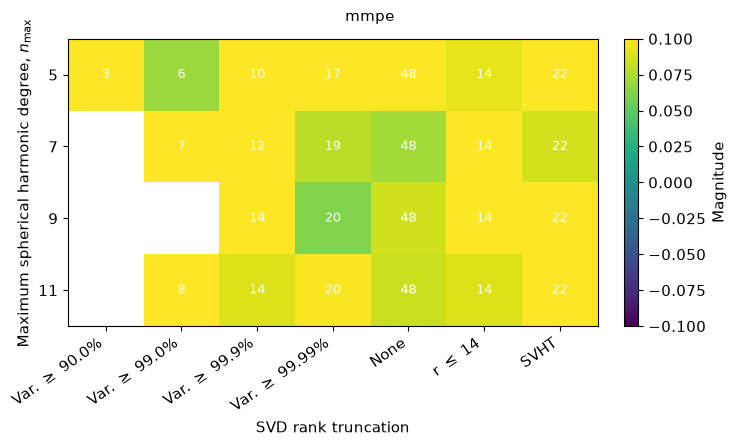

In [11]:

# nmax values to test
nmax_list = [5,7,9, 11]

# svd rank values to test
svd_rank_list = [0.9, 0.99, 0.999, 0.9999, -1, 2*len(mode_numbers), 0]

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":False,
    "embedding_d":9,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":10,
    "record_for_ensemble":"background"
}


Rank_Degree_Heatmap(record_dict_global, syn_suite_info_global, 
                    nmax_list, svd_rank_list, 
                    dmd_settings, ensemble_settings)



/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 422231.47173880273. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:639: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)


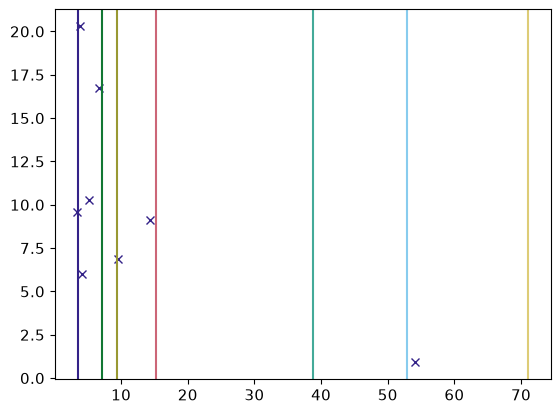

In [12]:
# getting control set from optimal recovery choice
dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":False,
    "embedding_d":9,
    "weight_flag":True
}
# make a set of 'recovered patterns' from var 99.9% and nmax = 9 - these act as like the input phasors

nmax_control = 9
svd_rank_control = 0.9999

gnm_background = record_dict_global["background"]
A_r = Truncate_Gauss_Coeffs(A_15_r, tmax=nmax_control)
gnm_background_truncate = Truncate_Gauss_Coeffs(gnm_background, tmax=nmax_control)

# projecting to grid
background_record = A_r @ gnm_background_truncate.T

# run DMD on background to get
recovered_modes = Run_DMD(background_record, times_used_relative, svd_rank=svd_rank_control, dmd_settings=dmd_settings)

# unpacking recovery
recovered_periods = np.asarray(recovered_modes["periods"])
recovered_eigenvalues = np.asarray(recovered_modes["continuous_eigenvalues"])
recovered_phasors = np.asarray(recovered_modes["phasors"])

# only retaining potentially realistic appearing modes
quality_factors = Mode_Quality_Factor(recovered_eigenvalues)
feasible_mask = ((recovered_periods < 25) & (recovered_periods > 2) & (quality_factors > 2))
plt.plot(recovered_periods, quality_factors, 'x')
for mode_key in syn_suite_info_global:
    mode_info = syn_suite_info_global[mode_key]
    colour = mode_info["colour"]
    period = mode_info["true_period"]
    plt.axvline(period, color=colour)

# recovering the base set

# pulling out the 'background derived control set'
control_phasors = recovered_phasors[feasible_mask]
control_eigenvalues = recovered_modes["continuous_eigenvalues"][feasible_mask]

num_modes = len(control_phasors)

control_modes = {}

for i in range(0, num_modes):

    control_modes[f"control_{i}"] = {
        "phasor":control_phasors[i],
        "eigenvalue":control_eigenvalues[i],
        "period":((2*np.pi)/(control_eigenvalues[i].imag)),
        "true_period":((2*np.pi)/(control_eigenvalues[i].imag)),
        "colour":"red"
    }


/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1402: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)


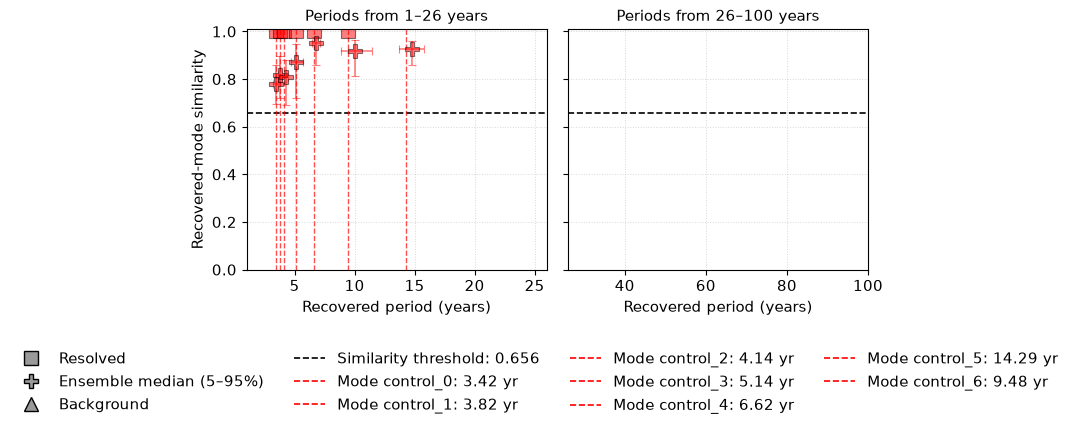

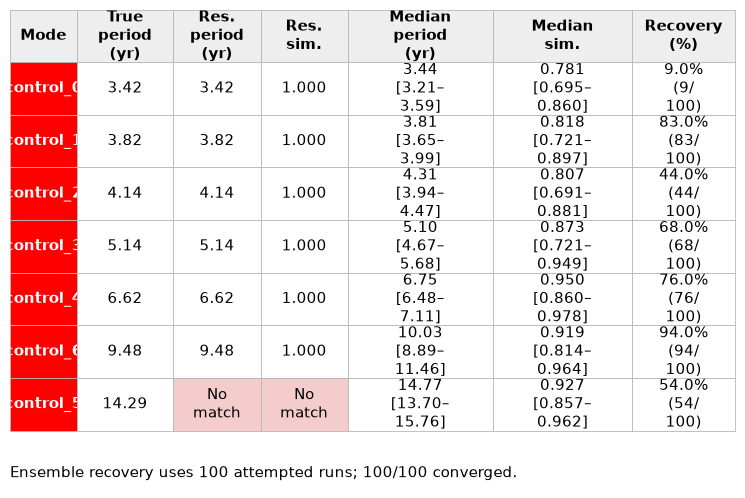

In [13]:


# specific exact case


# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":100,
    "record_for_ensemble":"resolved"
}

nmax_choice = nmax_control
svd_rank_choice = svd_rank_control

# getting output of dmd for a run with a specific nmax, svd rank
results_dict, total_unmatched_periods, rec_modes = Pipeline_Run({"resolved":gnm_background}, control_modes, 
        dmd_settings, nmax=nmax_choice, svd_rank=svd_rank_choice,
        ensemble_settings=ensemble_settings, syn_record=False, total_unmatched_period_return=True)


results_dict = Ensemble_To_Median(results_dict, control_modes)

similarity_threshold = similarity_thresholds["full_match"][str(nmax_choice)]

records_to_include = ["resolved","median"]

similarity_figure, similarity_axes = Plot_Period_Similarity_Results(
    results_dict, control_modes, similarity_threshold,
    record_markers, record_plotting_params, figure_width=text_width,
)

summary_figure, summary_table = Results_Summary_Table(results_dict, control_modes,
    records_to_include=records_to_include, ensemble_percentage_basis="attempted",
)
plt.show()

{'0': {'control_0': False, 'control_1': False, 'control_2': False, 'control_3': False, 'control_4': {'match_period_error': np.float64(0.06800671083723477), 'match_similarity': np.float64(0.9039668015193321), 'match_period': np.float64(7.0751568438947015)}, 'control_5': {'match_period_error': np.float64(0.14571302713553408), 'match_similarity': np.float64(0.9033092652584207), 'match_period': np.float64(16.369094543506595)}, 'control_6': {'match_period_error': np.float64(0.14611823581531003), 'match_similarity': np.float64(0.84771567227618), 'match_period': np.float64(10.863157998351646)}, 'match_count': 3, 'effective_rank': 20, 'feasible_count': 9}, '1': {'control_0': False, 'control_1': {'match_period_error': np.float64(0.0310107916243677), 'match_similarity': np.float64(0.8680053967897279), 'match_period': np.float64(3.9352640815802498)}, 'control_2': {'match_period_error': np.float64(0.06941957006511465), 'match_similarity': np.float64(0.7809987022490357), 'match_period': np.float64(

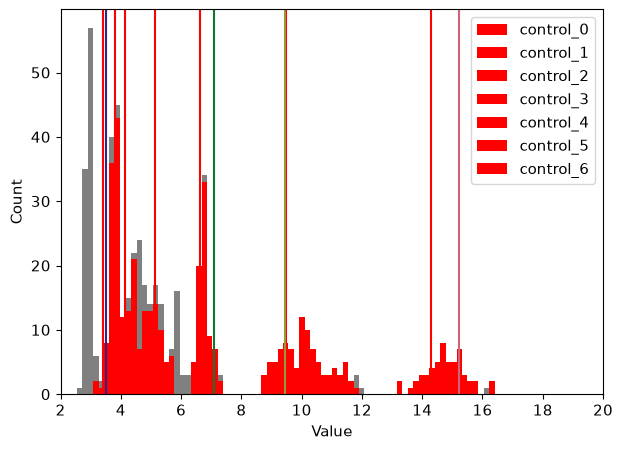

In [14]:
# from ensemble result, get period points by match
def By_Mode_Results(results_dict, mode_numbers):

    mode_period_recoveries = {}

    for mode_key in mode_numbers:
        mode_period_recoveries[mode_key] = []


    ensemble_result_dict = results_dict["ensemble"]
    print(ensemble_result_dict)

    for ensemble_i_key in ensemble_result_dict:
        ensemble_i_dict = ensemble_result_dict[ensemble_i_key]
        for mode_key in ensemble_i_dict:
            if ensemble_i_dict[mode_key] and type(ensemble_i_dict[mode_key])!=int:

                period = ensemble_i_dict[mode_key]["match_period"]
                mode_period_recoveries[mode_key].append(period)


    return(mode_period_recoveries)

by_mode_period_recoveries = By_Mode_Results(results_dict, control_modes.keys())

mode_keys = list(control_modes.keys())
values = [by_mode_period_recoveries[key] for key in mode_keys] + [total_unmatched_periods]
colours = [control_modes[key]["colour"] for key in mode_keys] + ["Gray"]

plt.figure(figsize=(7, 5))

for mode_key in control_modes:
   plt.axvline(control_modes[mode_key]["true_period"], color=control_modes[mode_key]["colour"])
for mode_key in syn_suite_info_global:
   plt.axvline(syn_suite_info_global[mode_key]["true_period"], color=syn_suite_info_global[mode_key]["colour"])


plt.hist(
    values,
    bins=100,
    stacked=True,
    color=colours,
    label=mode_keys,
    range=(2, 20)
)

plt.xlim((2, 20))
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.show()

In [15]:
# now trying hankel suite on background case


nmax_choice = 9
svd_rank_choice = 0.9999

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":False,
    "embedding_d":0,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":20,
    "record_for_ensemble":"background"
}

hankel_d_list = [0, 1, 2, 3, 4, 5, 6, 7, 8]
hankel_d_list = [0, 2, 4, 6, 8, 10, 12, 14, 16]
num_d = len(hankel_d_list)


# code to make heatmap - add into heatmap plotter at some point
d_match_results = {
    "median": np.zeros(num_d),
    "p95": np.zeros(num_d),
    "p05": np.zeros(num_d),
} 

# initialising mode performance outcomes
mode_recovery_performance = {}

for mode_num in syn_suite_info_global:
    mode_recovery_performance[mode_num] = {
        "match_similarities":np.zeros(num_d),
        "match_period_errors":np.ones(num_d),
        "runs_with_mode_match":np.zeros(num_d)
    }


# for each embedding d to be tested
for d_idx, embedding_d in enumerate(hankel_d_list):

    if embedding_d > 0:
        dmd_settings["hankel_flag"] = True
        dmd_settings["embedding_d"] = embedding_d


    # getting output of dmd for a run with a specific nmax, svd rank
    results_dict = Pipeline_Run(record_dict_global, syn_suite_info_global, 
            dmd_settings, nmax=nmax_choice, svd_rank=svd_rank_choice,
            ensemble_settings=ensemble_settings)

    results_dict = Ensemble_To_Median(results_dict, syn_suite_info_global)

    d_match_results["median"][d_idx] = results_dict["median"]["match_count"]["value"]
    d_match_results["p95"][d_idx] = results_dict["median"]["match_count"]["p95"]
    d_match_results["p05"][d_idx] = results_dict["median"]["match_count"]["p05"]

    # for each d - want the performance of each mode
    for mode_num in syn_suite_info_global:
        
        mode_results = results_dict["median"][mode_num]

        if mode_results:

            for key in mode_recovery_performance[mode_num]:

                try:

                    mode_recovery_performance[mode_num][key][d_idx] = (mode_results[key]["value"])

                except TypeError:

                    mode_recovery_performance[mode_num][key][d_idx] = (mode_results[key])

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 1.7329011410563832e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 33226613.65350601. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1592: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pyd

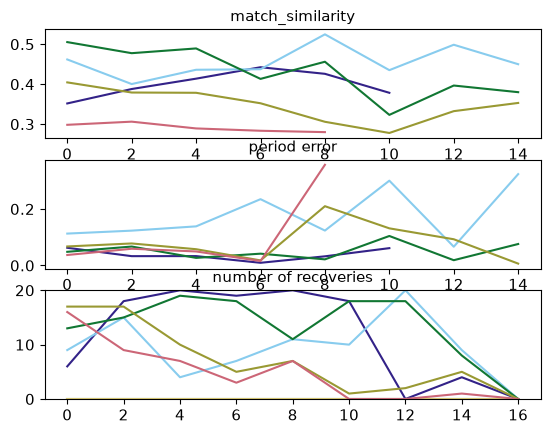

In [16]:
fig, axes = plt.subplots(ncols=1, nrows=3)
axes[0].set_title("match_similarity")
axes[1].set_title("period error")
axes[2].set_title("number of recoveries")
axes[2].set_ylim(0, 20)

for mode_num in mode_recovery_performance:

    mode_recovery_performance_i = mode_recovery_performance[mode_num]

    for i, key in enumerate(mode_recovery_performance_i):
        metric_plot = mode_recovery_performance[mode_num][key] 
        axes[i].plot(hankel_d_list, metric_plot, color=syn_suite_info_global[mode_num]["colour"])
    

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 198708.2777802396. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


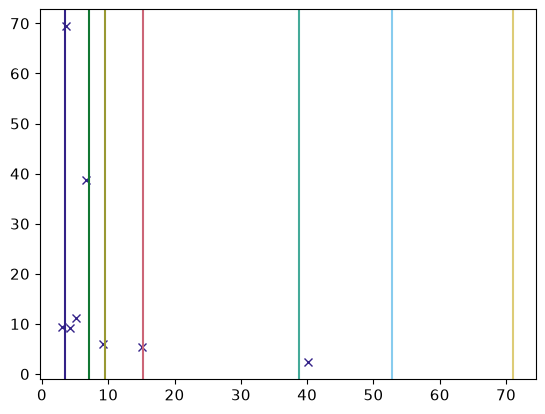

In [21]:
# getting control set from optimal recovery choice
dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":6,
    "weight_flag":True
}
# make a set of 'recovered patterns' from var 99.9% and nmax = 9 - these act as like the input phasors

nmax_control = 9
svd_rank_control = 0.9999

gnm_background = record_dict_global["background"]
A_r = Truncate_Gauss_Coeffs(A_15_r, tmax=nmax_control)
gnm_background_truncate = Truncate_Gauss_Coeffs(gnm_background, tmax=nmax_control)

# projecting to grid
background_record = A_r @ gnm_background_truncate.T

# run DMD on background to get
recovered_modes = Run_DMD(background_record, times_used_relative, svd_rank=svd_rank_control, dmd_settings=dmd_settings)

# unpacking recovery
recovered_periods = np.asarray(recovered_modes["periods"])
recovered_eigenvalues = np.asarray(recovered_modes["continuous_eigenvalues"])
recovered_phasors = np.asarray(recovered_modes["phasors"])

# only retaining potentially realistic appearing modes
quality_factors = Mode_Quality_Factor(recovered_eigenvalues)
feasible_mask = ((recovered_periods < 25) & (recovered_periods > 2) & (quality_factors > 2))
plt.plot(recovered_periods, quality_factors, 'x')
for mode_key in syn_suite_info_global:
    mode_info = syn_suite_info_global[mode_key]
    colour = mode_info["colour"]
    period = mode_info["true_period"]
    plt.axvline(period, color=colour)

# recovering the base set

# pulling out the 'background derived control set'
control_phasors = recovered_phasors[feasible_mask]
control_eigenvalues = recovered_modes["continuous_eigenvalues"][feasible_mask]

num_modes = len(control_phasors)

control_modes = {}

for i in range(0, num_modes):

    control_modes[f"control_{i}"] = {
        "phasor":control_phasors[i],
        "eigenvalue":control_eigenvalues[i],
        "period":((2*np.pi)/(control_eigenvalues[i].imag)),
        "true_period":((2*np.pi)/(control_eigenvalues[i].imag)),
        "colour":"red"
    }

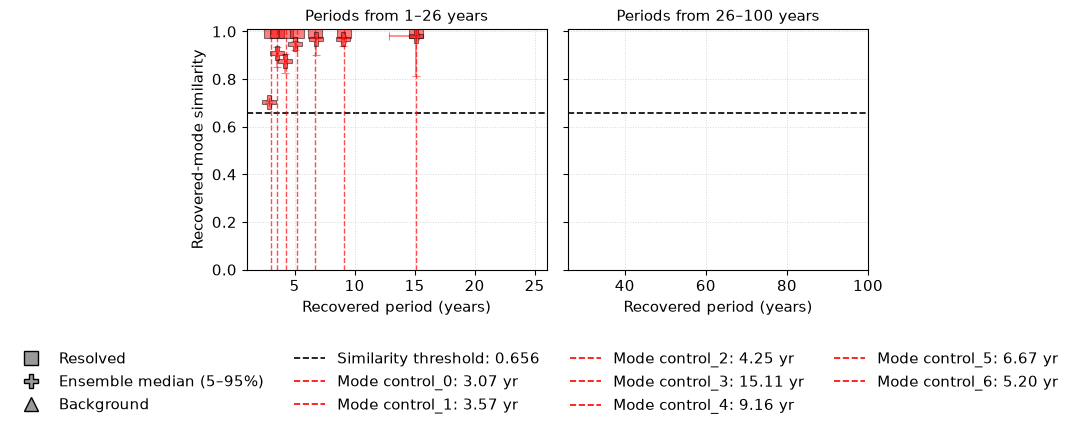

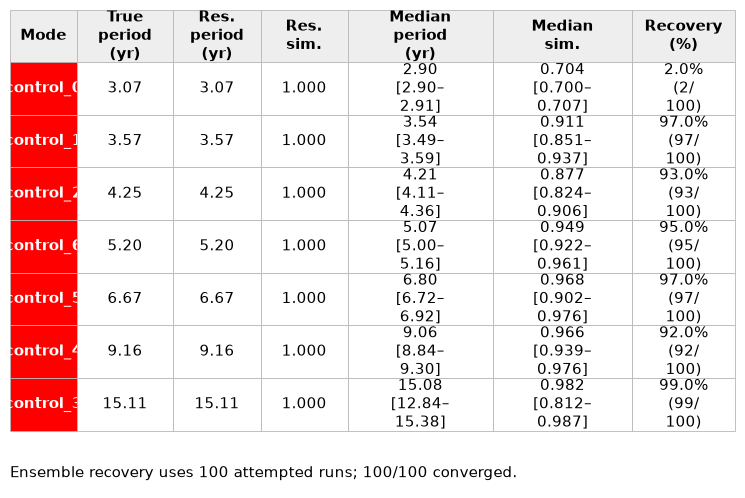

In [22]:


# specific exact case


# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":100,
    "record_for_ensemble":"resolved"
}

nmax_choice = nmax_control
svd_rank_choice = svd_rank_control

# getting output of dmd for a run with a specific nmax, svd rank
results_dict, total_unmatched_periods, rec_modes = Pipeline_Run({"resolved":gnm_background}, control_modes, 
        dmd_settings, nmax=nmax_choice, svd_rank=svd_rank_choice,
        ensemble_settings=ensemble_settings, syn_record=False, total_unmatched_period_return=True)


results_dict = Ensemble_To_Median(results_dict, control_modes)

similarity_threshold = similarity_thresholds["full_match"][str(nmax_choice)]

records_to_include = ["resolved","median"]

similarity_figure, similarity_axes = Plot_Period_Similarity_Results(
    results_dict, control_modes, similarity_threshold,
    record_markers, record_plotting_params, figure_width=text_width,
)

summary_figure, summary_table = Results_Summary_Table(results_dict, control_modes,
    records_to_include=records_to_include, ensemble_percentage_basis="attempted",
)
plt.show()

{'0': {'control_0': False, 'control_1': {'match_period_error': np.float64(0.0205232887798939), 'match_similarity': np.float64(0.891110055227197), 'match_period': np.float64(3.496545055161632)}, 'control_2': {'match_period_error': np.float64(0.00547895836964076), 'match_similarity': np.float64(0.8236442144256179), 'match_period': np.float64(4.222760709554092)}, 'control_3': {'match_period_error': np.float64(0.04568699550404452), 'match_similarity': np.float64(0.9718977739471949), 'match_period': np.float64(14.420571117279502)}, 'control_4': {'match_period_error': np.float64(0.010522135906777986), 'match_similarity': np.float64(0.9263233856358076), 'match_period': np.float64(9.059604271501371)}, 'control_5': {'match_period_error': np.float64(0.035610262993071434), 'match_similarity': np.float64(0.958927256301416), 'match_period': np.float64(6.908939195414347)}, 'control_6': {'match_period_error': np.float64(0.019606942323504427), 'match_similarity': np.float64(0.9421452580180304), 'match

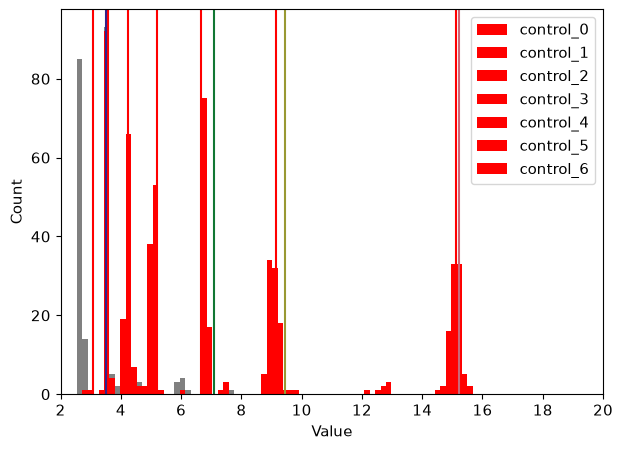

In [23]:
# from ensemble result, get period points by match
def By_Mode_Results(results_dict, mode_numbers):

    mode_period_recoveries = {}

    for mode_key in mode_numbers:
        mode_period_recoveries[mode_key] = []


    ensemble_result_dict = results_dict["ensemble"]
    print(ensemble_result_dict)

    for ensemble_i_key in ensemble_result_dict:
        ensemble_i_dict = ensemble_result_dict[ensemble_i_key]
        for mode_key in ensemble_i_dict:
            if ensemble_i_dict[mode_key] and type(ensemble_i_dict[mode_key])!=int:

                period = ensemble_i_dict[mode_key]["match_period"]
                mode_period_recoveries[mode_key].append(period)


    return(mode_period_recoveries)

by_mode_period_recoveries = By_Mode_Results(results_dict, control_modes.keys())

mode_keys = list(control_modes.keys())
values = [by_mode_period_recoveries[key] for key in mode_keys] + [total_unmatched_periods]
colours = [control_modes[key]["colour"] for key in mode_keys] + ["Gray"]

plt.figure(figsize=(7, 5))

for mode_key in control_modes:
   plt.axvline(control_modes[mode_key]["true_period"], color=control_modes[mode_key]["colour"])
for mode_key in syn_suite_info_global:
   plt.axvline(syn_suite_info_global[mode_key]["true_period"], color=syn_suite_info_global[mode_key]["colour"])


plt.hist(
    values,
    bins=100,
    stacked=True,
    color=colours,
    label=mode_keys,
    range=(2, 20)
)

plt.xlim((2, 20))
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.show()

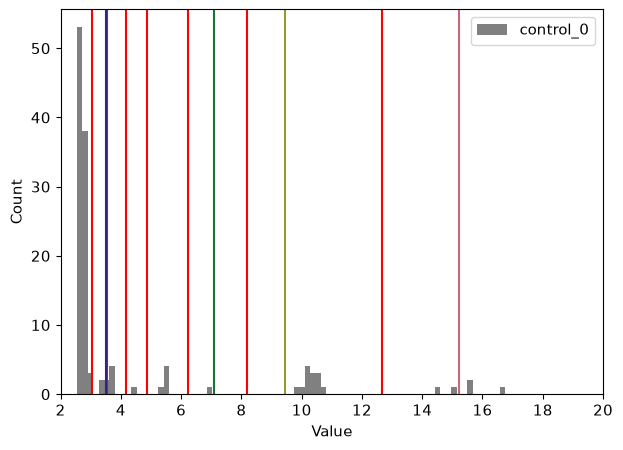

In [21]:

values = [total_unmatched_periods]
colours = ["Gray"]

plt.figure(figsize=(7, 5))

for mode_key in control_modes:
   plt.axvline(control_modes[mode_key]["true_period"], color=control_modes[mode_key]["colour"])
for mode_key in syn_suite_info_global:
   plt.axvline(syn_suite_info_global[mode_key]["true_period"], color=syn_suite_info_global[mode_key]["colour"])


plt.hist(
    values,
    bins=100,
    stacked=True,
    color=colours,
    label=mode_keys,
    range=(2, 20)
)

plt.xlim((2, 20))
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.show()

In [ ]:
# visualise - what do they look like? period vs power here maybe - colour correct modes, black for spurious

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 476944.82513753616. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1401: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1592: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 387535.46542788314. Consider

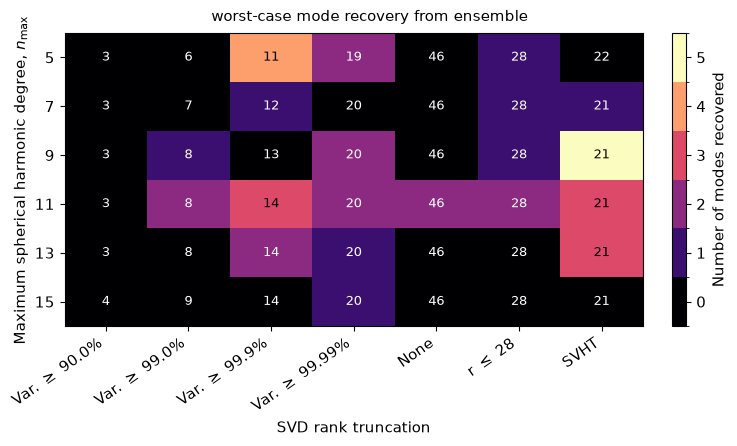

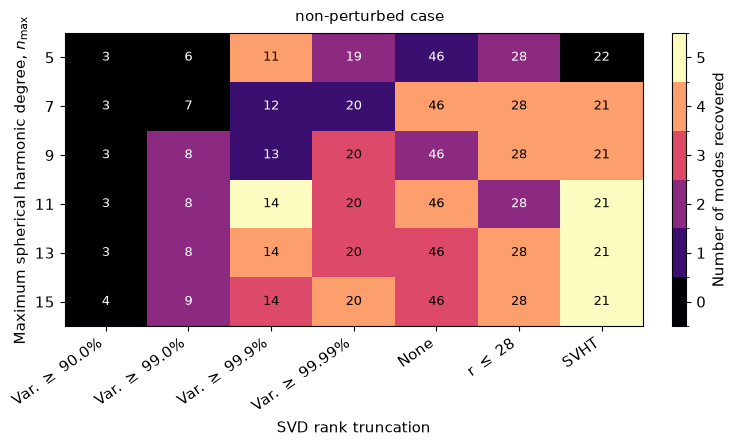

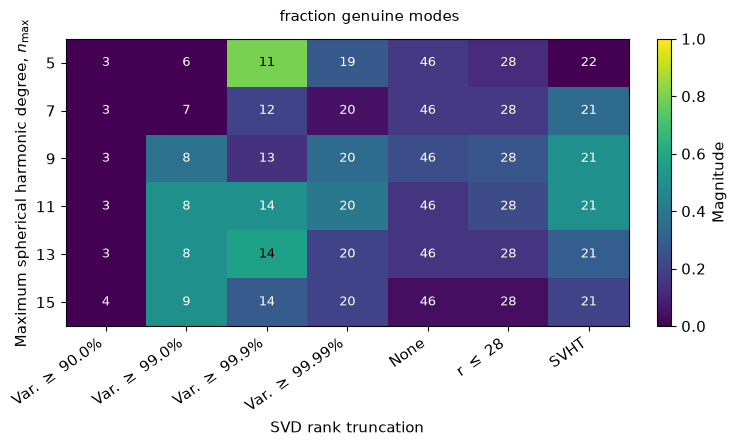

In [10]:


# nmax values to test
nmax_list = [5, 7, 9, 11, 13, 15]
# svd rank values to test
svd_rank_list = [0.9, 0.99, 0.999, 0.9999, -1, 2*14, 0]
svd_rank_labels = Make_SVD_Labels(svd_rank_list)


dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":3,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":10,
    "record_for_ensemble":"resolved"
}

Rank_Degree_Heatmap({"resolved":gnm_background}, control_modes, 
                    nmax_list, svd_rank_list, 
                    dmd_settings, ensemble_settings, syn_record=False)